In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from PIL import Image

In [2]:
def MHD1d_sd2_frames(J, N, P, dt_out=0.005):
    os.chdir('/Users/evandaniels/Research/CentPackL/simulation_MHD1d_SD2')
    os.makedirs('rho_frames', exist_ok=True)
    os.makedirs('u1_frames', exist_ok=True)
    os.makedirs('u2_frames', exist_ok=True)
    os.makedirs('u3_frames', exist_ok=True)
    os.makedirs('b2_frames', exist_ok=True)
    os.makedirs('b3_frames', exist_ok=True)
    os.makedirs('p_frames',  exist_ok=True)

    # Load mesh
    x = []
    for p in range(P):
        xp = np.loadtxt(f'mesh_files/x_p{p:03d}')
        x.append(xp)
    x = np.concatenate(x)

    variables = ['rho', 'u1', 'u2', 'u3', 'b2', 'b3', 'p']
    ylabels   = ['Density', 'Velocity $u_1$', 'Velocity $u_2$',
                 'Velocity $u_3$', '$B_2$', '$B_3$', 'Pressure']

    for n in range(N + 1):
        t = n * dt_out
        for var, ylabel in zip(variables, ylabels):
            data = []
            for p in range(P):
                dp = np.loadtxt(f'{var}_files/{var}_p{p:03d}_{n:03d}')
                data.append(dp)
            data = np.concatenate(data)

            fig, ax = plt.subplots()
            ax.plot(x, data, '-', linewidth=2)
            ax.set_xlabel('x')
            ax.set_ylabel(ylabel)
            ax.set_title(f'{ylabel}  —  t = {t:.3f}')
            ax.set_xlim(-1.0, 1.0)
            fig.savefig(f'{var}_frames/{var}_{n:03d}.png', dpi=72)
            plt.close(fig)

        # print(f'Saved frame {n}/{N}')

In [3]:
MHD1d_sd2_frames(J=100, N=40, P=8)

In [6]:
def frames_to_gif(frame_dir, output_name, duration=100):
    frames = sorted(glob.glob(f'{frame_dir}/*.png'))
    images = [Image.open(f) for f in frames]
    images[0].save(
        output_name,
        save_all=True,
        append_images=images[1:],
        loop=0,
        duration=duration  # milliseconds per frame
    )

frames_to_gif('rho_frames', 'rho.gif')
frames_to_gif('u1_frames',  'u1.gif')
frames_to_gif('u2_frames',  'u2.gif')
frames_to_gif('u3_frames',  'u3.gif')
frames_to_gif('b2_frames',  'b2.gif')
frames_to_gif('b3_frames',  'b3.gif')
frames_to_gif('p_frames',   'p.gif')

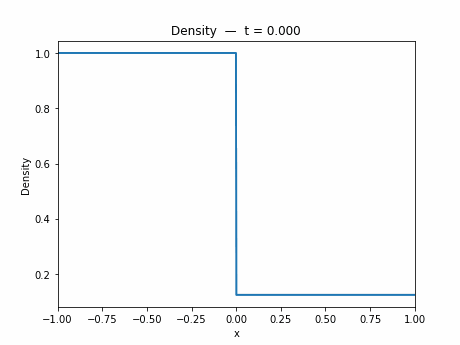

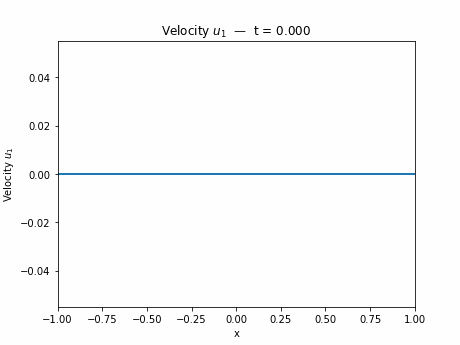

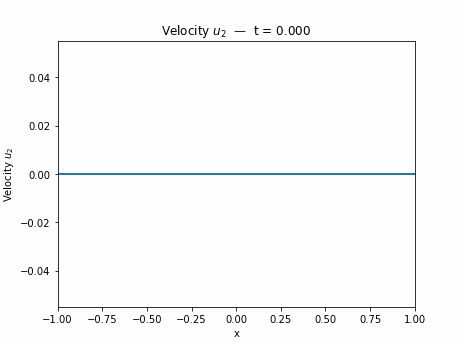

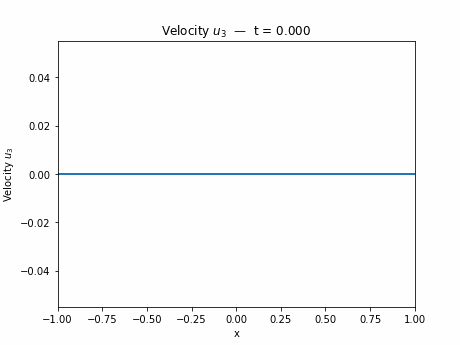

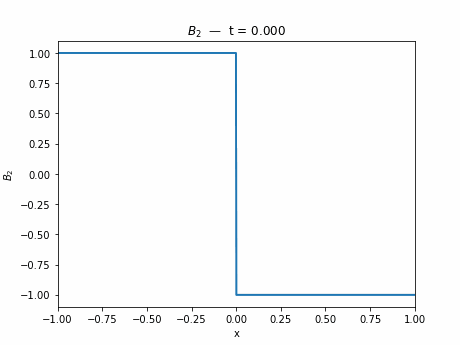

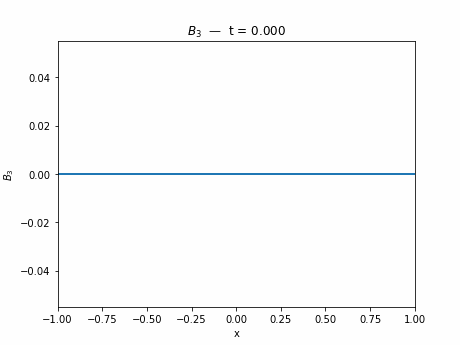

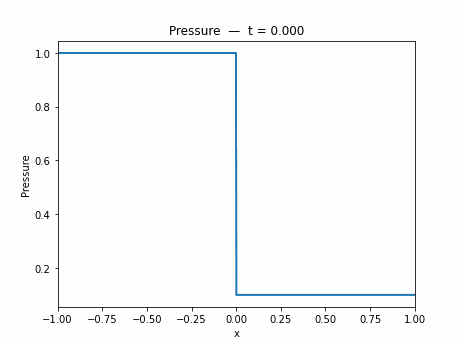

In [7]:
from IPython.display import Image as IPImage
display(IPImage('rho.gif'),
IPImage('u1.gif'),
IPImage('u2.gif'),
IPImage('u3.gif'),
IPImage('b2.gif'),
IPImage('b3.gif'),
IPImage('p.gif'))